<a href="https://colab.research.google.com/github/Navya449/Victim_detection/blob/main/Victim_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!pip install librosa
!pip install soundfile
!pip install tensorflow
!pip install scikit-learn

In [12]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [13]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
from google.colab import drive
import os
import shutil

# Attempt to clean up the mount point if it's not actually mounted
path = '/content/drive'
if os.path.exists(path) and not os.path.ismount(path):
    print(f'Removing existing local directory {path} to allow mounting...')
    shutil.rmtree(path)

try:
    drive.mount(path, force_remount=True)
except Exception as e:
    print(f'Mount failed: {e}')

Mounted at /content/drive


In [15]:
import os

project_path = "/content/drive/MyDrive/Victim_Voice_Project"

print(os.path.exists(project_path))

True


In [16]:
!wget https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz

--2026-07-09 15:55:52--  https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 74.125.137.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2428923189 (2.3G) [application/gzip]
Saving to: ‘speech_commands_v0.02.tar.gz’

speech_commands_v0. 100%[===================>]   2.26G  59.7MB/s    in 18s     

2026-07-09 15:56:10 (131 MB/s) - ‘speech_commands_v0.02.tar.gz’ saved [2428923189/2428923189]



In [17]:
!tar -xzf speech_commands_v0.02.tar.gz

In [18]:
!ls

_background_noise_  forward  off			   test_case.wav
backward	    four     on				   testing_list.txt
bed		    go	     one			   three
bird		    happy    README.md			   tree
cat		    house    right			   two
dog		    learn    sample_data		   up
down		    left     seven			   validation_list.txt
drive		    LICENSE  sheila			   visual
eight		    marvin   six			   wow
five		    nine     speech_commands_v0.02.tar.gz  yes
follow		    no	     stop			   zero


In [19]:
import os

count = 0

for folder in os.listdir():
    if os.path.isdir(folder):
        for file in os.listdir(folder):
            if file.endswith(".wav"):
                count += 1

print("Total speech files:", count)

Total speech files: 105835


In [20]:
import os

noise_folder = "_background_noise_"

print(os.listdir(noise_folder))

['dude_miaowing.wav', 'running_tap.wav', 'pink_noise.wav', 'doing_the_dishes.wav', 'white_noise.wav', 'exercise_bike.wav', 'README.md']


In [21]:
import os

os.makedirs("dataset/voice", exist_ok=True)
os.makedirs("dataset/noise", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [22]:
import os

base_path = "/content/drive/MyDrive/Victim_Voice_Project"

os.makedirs(os.path.join(base_path, "dataset", "voice"), exist_ok=True)
os.makedirs(os.path.join(base_path, "dataset", "noise"), exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [23]:
import os
import shutil

commands = [
    "yes",
    "no",
    "up",
    "down",
    "left",
    "right",
    "go",
    "stop",
    "on",
    "off"
]

count = 0

for command in commands:
    for file in os.listdir(command):
        if file.endswith(".wav"):
            src = os.path.join(command, file)
            dst = os.path.join("dataset/voice", command + "_" + file)
            shutil.copy(src, dst)
            count += 1

print("Voice files copied:", count)

Voice files copied: 38546


In [24]:
import librosa
import soundfile as sf
import os

noise_folder = "_background_noise_"
output_folder = "dataset/noise"

sample_rate = 16000
clip_length = sample_rate   # 1 second

clip_number = 0

for file in os.listdir(noise_folder):

    if not file.endswith(".wav"):
        continue

    audio, sr = librosa.load(
        os.path.join(noise_folder, file),
        sr=sample_rate
    )

    total_clips = len(audio) // clip_length

    for i in range(total_clips):

        start = i * clip_length
        end = start + clip_length

        clip = audio[start:end]

        sf.write(
            os.path.join(output_folder, f"noise_{clip_number}.wav"),
            clip,
            sample_rate
        )

        clip_number += 1

print("Noise clips created:", clip_number)

Noise clips created: 398


In [25]:
import os

voice_path = "dataset/voice"
noise_path = "dataset/noise"

voice_count = len([f for f in os.listdir(voice_path) if f.endswith(".wav")])
noise_count = len([f for f in os.listdir(noise_path) if f.endswith(".wav")])

print("Voice files :", voice_count)
print("Noise files :", noise_count)

Voice files : 38546
Noise files : 398


In [26]:
import os

print(os.listdir("dataset"))

['noise', 'voice']


In [27]:
import os
import librosa
import numpy as np
import random
from tqdm import tqdm

In [28]:
X = []
y = []

In [29]:
voice_folder = "dataset/voice"

voice_files = [
    f for f in os.listdir(voice_folder)
    if f.endswith(".wav")
]

random.seed(42)

voice_files = random.sample(voice_files, 398)

print(len(voice_files))

398


In [30]:
for file in tqdm(voice_files):

    path = os.path.join(voice_folder, file)

    signal, sr = librosa.load(path, sr=16000)

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=40
    )

    if mfcc.shape[1] < 32:
        mfcc = np.pad(
            mfcc,
            ((0,0),(0,32-mfcc.shape[1])),
            mode="constant"
        )
    else:
        mfcc = mfcc[:, :32]

    X.append(mfcc)
    y.append("voice")

100%|██████████| 398/398 [00:05<00:00, 68.83it/s] 


In [31]:
noise_folder = "dataset/noise"

noise_files = [
    f for f in os.listdir(noise_folder)
    if f.endswith(".wav")
]

print(len(noise_files))

398


In [32]:
for file in tqdm(noise_files):

    path = os.path.join(noise_folder, file)

    signal, sr = librosa.load(path, sr=16000)

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=40
    )

    if mfcc.shape[1] < 32:
        mfcc = np.pad(
            mfcc,
            ((0,0),(0,32-mfcc.shape[1])),
            mode="constant"
        )
    else:
        mfcc = mfcc[:, :32]

    X.append(mfcc)
    y.append("noise")

100%|██████████| 398/398 [00:01<00:00, 199.94it/s]


In [33]:
X = np.array(X)
y = np.array(y)

print("Features :", X.shape)
print("Labels :", y.shape)

Features : (796, 40, 32)
Labels : (796,)


In [34]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(encoder.classes_)
print(y[:10])

['noise' 'voice']
[1 1 1 1 1 1 1 1 1 1]


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (636, 40, 32)
Testing Samples : (160, 40, 32)


In [36]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)
print(X_test.shape)

(636, 40, 32, 1)
(160, 40, 32, 1)


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(40,32,1)
))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.3))

model.add(Dense(
    2,
    activation='softmax'
))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,418 (1.57 MB)

 Trainable params: 412,418 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [40]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "victim_voice_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [41]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.6887 - loss: 2.3427 - val_accuracy: 0.9375 - val_loss: 0.2183
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9198 - loss: 0.2095 - val_accuracy: 0.9937 - val_loss: 0.0708
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9811 - loss: 0.0691 - val_accuracy: 0.9937 - val_loss: 0.0299
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9921 - loss: 0.0277 - val_accuracy: 0.9937 - val_loss: 0.0200
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9953 - loss: 0.0203 - val_accuracy: 0.9937 - val_loss: 0.0159
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9984 - loss: 0.0100 - val_accuracy: 0.9875 - val_loss: 0.0186
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.9937 - val_loss: 0.0210
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9875 - val_lo

In [42]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9984 - loss: 0.0102 - val_accuracy: 0.9937 - val_loss: 0.0171
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9984 - loss: 0.0111 - val_accuracy: 0.9875 - val_loss: 0.0206
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9937 - loss: 0.0145 - val_accuracy: 0.9812 - val_loss: 0.0269
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9953 - loss: 0.0187 - val_accuracy: 0.9750 - val_loss: 0.0529
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9984 - loss: 0.0064 - val_accuracy: 0.9937 - val_loss: 0.0114
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9937 - val_loss: 0.0260
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9921 - loss: 0.0229 - val_accuracy: 0.9937 - val_loss: 0.0318
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9937 - loss: 0.0270 - val_accuracy: 1.0000 - va

In [43]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0042 
Test Loss: 0.004241822753101587
Test Accuracy: 1.0


In [44]:
import numpy as np

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  


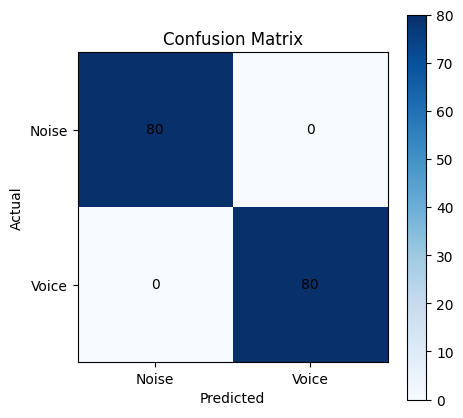

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Noise","Voice"])
plt.yticks([0,1], ["Noise","Voice"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha='center',
                 va='center',
                 color='black')

plt.show()

In [46]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Noise","Voice"]
))

              precision    recall  f1-score   support

       Noise       1.00      1.00      1.00        80
       Voice       1.00      1.00      1.00        80

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



# New Section

In [47]:
model.save("victim_voice_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [48]:
import json

labels = {
    0: "noise",
    1: "voice"
}

with open("labels.json", "w") as f:
    json.dump(labels, f)

print("Labels Saved")

Labels Saved


In [49]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("victim_voice_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TensorFlow Lite Model Saved")

Saved artifact at '/tmp/tmpzf45d2yg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 32, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  138003006990160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138003006992464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138000830297872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138000830298832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138000830289040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138000830290192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138000830288464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138000830287120: TensorSpec(shape=(), dtype=tf.resource, name=None)
TensorFlow Lite Model Saved


Verification

In [56]:
import os

print("Current Directory:", os.getcwd())
print("\nFiles:")
print(os.listdir())

Current Directory: /content

Files:
['.config', 'forward', 'sheila', 'victim_voice_model.keras', 'one', '.ipynb_checkpoints', 'left', 'labels.json', 'six', '_background_noise_', 'three', 'two', 'yes', 'backward', 'house', 'LICENSE', 'bird', 'visual', 'testing_list.txt', 'learn', 'tree', '.DS_Store', 'cat', 'dataset', 'up', 'eight', 'drive', 'no', 'bed', 'validation_list.txt', 'down', 'nine', 'go', 'on', 'five', 'follow', 'four', 'right', 'victim_voice_model.tflite', 'test_case.wav', 'stop', 'happy', 'dog', 'seven', 'zero', 'wow', 'README.md', 'off', 'speech_commands_v0.02.tar.gz', 'marvin', 'sample_data']


In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import os

drive_path = "/content/drive/MyDrive"

print("Folders in MyDrive:\n")

for item in os.listdir(drive_path):
    print(item)

Folders in MyDrive:

Colab Notebooks
Human_Sound_Localization_AI
Victim_Detection
Victim_Voice_Project


In [53]:
import os

project_path = "/content/drive/MyDrive/Victim_Detection"

print("Contents of Victim_Detection:\n")

for root, dirs, files in os.walk(project_path):
    print("Folder:", root)
    for file in files:
        print("   ", file)

Contents of Victim_Detection:

Folder: /content/drive/MyDrive/Victim_Detection
Folder: /content/drive/MyDrive/Victim_Detection/models


In [52]:
import os

project_path = "/content/drive/MyDrive/Human_Sound_Localization_AI"

print("Contents of Human_Sound_Localization_AI:\n")

for root, dirs, files in os.walk(project_path):
    print("\nFolder:", root)
    for file in files:
        print("   ", file)

Contents of Human_Sound_Localization_AI:


Folder: /content/drive/MyDrive/Human_Sound_Localization_AI

Folder: /content/drive/MyDrive/Human_Sound_Localization_AI/dataset

Folder: /content/drive/MyDrive/Human_Sound_Localization_AI/models

Folder: /content/drive/MyDrive/Human_Sound_Localization_AI/outputs

Folder: /content/drive/MyDrive/Human_Sound_Localization_AI/notebooks

Folder: /content/drive/MyDrive/Human_Sound_Localization_AI/src


In [51]:
import os

dataset_path = "/content/drive/MyDrive/Human_Sound_Localization_AI/dataset"

print("Dataset Contents:\n")

for root, dirs, files in os.walk(dataset_path):
    print("\nFolder:", root)
    print("Number of files:", len(files))

    for file in files[:10]:   # Show only the first 10 files
        print("   ", file)


Dataset Contents:


Folder: /content/drive/MyDrive/Human_Sound_Localization_AI/dataset
Number of files: 0


In [50]:
print("model" in globals())
print("X_train" in globals())
print("mfcc" in globals())

True
True
True


In [57]:
print(model.input_shape)

(None, 40, 32, 1)


In [58]:
import librosa
import numpy as np

signal, sr = librosa.load("test_case.wav", sr=16000)

print("Sample Rate:", sr)
print("Signal Length:", len(signal))


/tmp/ipykernel_535/2102037184.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load("test_case.wav", sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Sample Rate: 16000
Signal Length: 45398


In [59]:
mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=40
)

print("Original MFCC Shape:", mfcc.shape)

Original MFCC Shape: (40, 89)


In [60]:
if mfcc.shape[1] < 32:
    mfcc = np.pad(
        mfcc,
        ((0, 0), (0, 32 - mfcc.shape[1])),
        mode="constant"
    )
else:
    mfcc = mfcc[:, :32]

print("Resized MFCC Shape:", mfcc.shape)

Resized MFCC Shape: (40, 32)


In [61]:
mfcc = mfcc.reshape(1, 40, 32, 1)

print("Final Input Shape:", mfcc.shape)

Final Input Shape: (1, 40, 32, 1)


In [63]:
prediction = model.predict(mfcc)

print("Raw Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Raw Prediction: [[0.99814034 0.00185962]]


In [64]:
import numpy as np

labels = {
    0: "Noise",
    1: "Voice"
}

predicted_class = np.argmax(prediction)

print("Prediction:", labels[predicted_class])
print("Confidence:", round(float(prediction[0][predicted_class]) * 100, 2), "%")

Prediction: Noise
Confidence: 99.81 %
